In [25]:
from src.utils import (
    get_model_and_config,
    keypoint_unscaler,
)
from src.utils import extract_keypoints
import torch
import cv2
import inspect
import json
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
model_name = "heatmap"
model, cfg = get_model_and_config(model_name)

In [26]:
# def config_to_dict(config):
#     """Convert a config object (or class) to a serializable dictionary."""
#     if inspect.isclass(config):
#         # Handle class (like BaseConfig)
#         attrs = {k: v for k, v in vars(config).items() 
#                 if not k.startswith('__') and not callable(v)}
#     else:
#         # Handle instance (like HeatmapConfig)
#         attrs = {k: v for k, v in vars(config).items() 
#                 if not k.startswith('__') and k != 'base' and not callable(v)}
    
#     # Handle nested base config
#     if hasattr(config, 'base'):
#         attrs['__base_config__'] = config_to_dict(config.base)
    
#     # Handle non-serializable objects (simplified)
#     for k, v in attrs.items():
#         if isinstance(v, torch.device):
#             attrs[k] = str(v)
#         elif isinstance(v, torch.nn.Module):
#             attrs[k] = v.__class__.__name__  # Save only the class name
    
#     return attrs

# # Example usage:
# model_name = "heatmap"
# config_dict = config_to_dict(cfg)
# with open(f'{model_name}_config.json', 'w') as f:
#     json.dump(config_dict, f, indent=4)

In [27]:
# def dict_to_config(d, model_config, base_config_class=None):
#     """Reconstruct a ModelConfig from a dictionary."""
#     base_dict = d.pop('__base_config__', None)
#     if base_dict and base_config_class:
#         base_config = base_config_class()
#         for k, v in base_dict.items():
#             setattr(base_config, k, v)
#     else:
#         base_config = None
    
#     config = model_config(base_config=base_config_class)
#     for k, v in d.items():
#         setattr(config, k, v)
    
#     return config

# # Example reloading:
# with open(f'{model_name}_config.json', 'r') as f:
#     loaded_dict = json.load(f)

# from config import BaseConfig, ModelConfig
# loaded_config = dict_to_config(loaded_dict, ModelConfig, BaseConfig)


# loaded_config.learn_rate

In [28]:
# from src.inference import VideoProcessor

# video_path = "https://www.youtube.com/watch?v=oyxhHkOel2I&ab_channel=AustralianOpenTV"
# video_name = "tennis_match"

# video = VideoProcessor(
#     video_path,
#     video_name,
#     output_path="tennis_match",
#     folder="examples",
#     max_duration=None,
#     start_time=33,
#     end_time=45
# )()

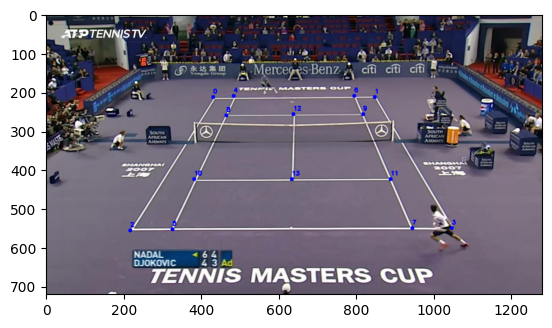

In [29]:
import matplotlib.pyplot as plt

class CourtLineDetector:
    def __init__(self, cfg, model, load_model):
        self.model = model
        self.model.load_state_dict(torch.load(load_model, map_location='cpu'))
        self.model = self.model.to(cfg.device)
        self.model.eval()
        self.cfg = cfg
        self.width = cfg.width
        self.height = cfg.height
        
        self.transform = A.Compose([
            A.Resize(width=cfg.width, height=cfg.height),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2(p=1.0),
        ])

    def predict(self, image_path):
        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        original_h, original_w = image.shape[:2]
        image_tensor = self.transform(image=image)["image"].unsqueeze(0)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(image_tensor.to(self.cfg.device))

        if self.cfg.model_name == "ResNetHeatmap":
            keypoints = extract_keypoints(outputs)
            keypoints = keypoints.squeeze().cpu().numpy()
        else:
            keypoints = outputs.squeeze().cpu().numpy()


        keypoints = keypoint_unscaler(
            cfg, keypoints, original_w, original_h
        )
        return keypoints

    def draw_keypoints(self, image_path, keypoints):
        if keypoints.ndim == 2:
            keypoints = keypoints.flatten()

        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        image = image.copy()
        for i in range(0, len(keypoints), 2):
            x = int(keypoints[i])
            y = int(keypoints[i+1])
            cv2.putText(image, str(i//2), (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            cv2.circle(image, (x, y), 5, (0, 0, 255), -1)
        plt.imshow(image)
    
image_path = cfg.sample_image_path[3]

detector = CourtLineDetector(cfg, model, "sample_images/trial1/heatmap_pretrained_resnet18_672x448.pth")
keypoints = detector.predict(image_path)
detector.draw_keypoints(image_path, keypoints)


## Test on video

In [ ]:
import cv2
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from typing import Generator, Optional
import numpy as np
from typing import Optional, List


class CourtLineDetector:
    def __init__(self, cfg, model, load_model):
        self.model = model
        self.model.load_state_dict(torch.load(load_model, map_location='cpu'))
        self.model = self.model.to(cfg.device)
        self.model.eval()
        self.cfg = cfg
        self.width = cfg.width
        self.height = cfg.height
        
        self.transform = A.Compose([
            A.Resize(width=cfg.width, height=cfg.height),
            A.Normalize(mean=cfg.mean, std=cfg.std),
            ToTensorV2(p=1.0),
        ])

    def predict(self, image_path):
        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        original_h, original_w = image.shape[:2]
        image_tensor = self.transform(image=image)["image"].unsqueeze(0)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(image_tensor.to(self.cfg.device))

        if self.cfg.model_name == "ResNetHeatmap":
            keypoints = extract_keypoints(outputs)
            keypoints = keypoints.squeeze().cpu().numpy()
        else:
            keypoints = outputs.squeeze().cpu().numpy()

        keypoints = keypoint_unscaler(
            cfg, keypoints, original_w, original_h
        )
        return keypoints

    def predict_frame(self, frame: np.ndarray) -> np.ndarray:
        """Predict keypoints for a single frame"""
        if len(frame.shape) == 3:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        else:
            frame_rgb = frame
            
        original_h, original_w = frame_rgb.shape[:2]
        image_tensor = self.transform(image=frame_rgb)["image"].unsqueeze(0)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(image_tensor.to(self.cfg.device))

        if self.cfg.model_name == "ResNetHeatmap":
            keypoints = extract_keypoints(outputs)
            keypoints = keypoints.squeeze().cpu().numpy()
        else:
            keypoints = outputs.squeeze().cpu().numpy()

        keypoints = keypoint_unscaler(self.cfg, keypoints, original_w, original_h)
        return keypoints

    def process_video(self, video_path: str, output_path: Optional[str] = None, 
                     fps: Optional[int] = None, show_preview: bool = False):
        """
        Process video frame by frame and yield keypoints for each frame
        
        Args:
            video_path: Path to input video file
            output_path: Optional path to save output video with keypoints
            fps: Optional target FPS for output video
            show_preview: Whether to show real-time preview
        
        Yields:
            tuple: (frame_number, keypoints_array, frame_with_keypoints)
        """
        cap = cv2.VideoCapture(video_path)
        
        if not cap.isOpened():
            raise ValueError(f"Could not open video: {video_path}")
        
        original_fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            target_fps = fps if fps else original_fps
            writer = cv2.VideoWriter(output_path, fourcc, target_fps, (width, height))
        
        frame_count = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
                
            keypoints = self.predict_frame(frame)
            frame_with_keypoints = self.draw_keypoints_on_frame(frame, keypoints)
            
            if writer:
                writer.write(frame_with_keypoints)
            
            if show_preview:
                cv2.imshow('Court Line Detection', frame_with_keypoints)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break
            
            yield frame_count, keypoints, frame_with_keypoints
            frame_count += 1
            
            print(f"Processed frame {frame_count}/{total_frames}", end='\r')
        
        cap.release()
        if writer:
            writer.release()
        if show_preview:
            cv2.destroyAllWindows()
        
        print(f"\nVideo processing complete. Processed {frame_count} frames.")

    def draw_keypoints(self, image_path, keypoints):
        if keypoints.ndim == 2:
            keypoints = keypoints.flatten()

        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        image = image.copy()
        for i in range(0, len(keypoints), 2):
            x = int(keypoints[i])
            y = int(keypoints[i+1])
            cv2.putText(image, str(i//2), (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            cv2.circle(image, (x, y), 5, (0, 0, 255), -1)
        plt.imshow(image)

    def draw_keypoints_on_frame(self, frame: np.ndarray, keypoints: np.ndarray) -> np.ndarray:
        """Draw keypoints on a frame (BGR format)"""
        if keypoints.ndim == 2:
            keypoints = keypoints.flatten()

        frame_copy = frame.copy()
        for i in range(0, len(keypoints), 2):
            x = int(keypoints[i])
            y = int(keypoints[i+1])
            # Ensure coordinates are within frame bounds
            x = max(0, min(x, frame_copy.shape[1] - 1))
            y = max(0, min(y, frame_copy.shape[0] - 1))
            
            cv2.putText(frame_copy, str(i//2), (x, y-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            cv2.circle(frame_copy, (x, y), 5, (0, 0, 255), -1)
        return frame_copy

    def predict_batch(self, frames: List[np.ndarray]) -> List[np.ndarray]:
        batch_tensors = []
        original_shapes = []
        
        for frame in frames:
            if len(frame.shape) == 3:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            else:
                frame_rgb = frame
                
            original_h, original_w = frame_rgb.shape[:2]
            original_shapes.append((original_w, original_h))
            
            image_tensor = self.transform(image=frame_rgb)["image"]
            batch_tensors.append(image_tensor)
        
        batch_tensors = torch.stack(batch_tensors).to(self.cfg.device)
        
        with torch.no_grad():
            outputs = self.model(batch_tensors)
        
        keypoints_list = []
        for i, output in enumerate(outputs):
            if self.cfg.model_name == "ResNetHeatmap":
                keypoints = extract_keypoints(output.unsqueeze(0))
                keypoints = keypoints.squeeze().cpu().numpy()
            else:
                keypoints = output.squeeze().cpu().numpy()
            
            original_w, original_h = original_shapes[i]
            keypoints = keypoint_unscaler(self.cfg, keypoints, original_w, original_h)
            keypoints_list.append(keypoints)
        
        return keypoints_list
    
def batch_process_and_save_video(detector, video_path: str, output_path: str, 
                                batch_size: int = 16) -> None:
    cap = cv2.VideoCapture(video_path)
    
    # Get video properties
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(
        output_path, fourcc, original_fps, (width, height)
    )
    
    frames_batch = []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frames_batch.append(frame)
        
        if len(frames_batch) == batch_size:
            keypoints_batch = detector.predict_batch(frames_batch)
            for frame, keypoints in zip(frames_batch, keypoints_batch):
                frame_with_kps = detector.draw_keypoints_on_frame(frame, keypoints)
                writer.write(frame_with_kps)
            
            frames_batch = []
    
    if frames_batch:
        keypoints_batch = detector.predict_batch(frames_batch)
        for frame, keypoints in zip(frames_batch, keypoints_batch):
            frame_with_kps = detector.draw_keypoints_on_frame(frame, keypoints)
            writer.write(frame_with_kps)
    
    cap.release()
    writer.release()
    print(f"Video saved to: {output_path}")

video_path = "examples/tennis_match_shortened.mp4"
detector = CourtLineDetector(
    cfg, model, "sample_images/trial1/heatmap_pretrained_resnet18_672x448.pth"
)

detector.process_video(
    video_path=video_path,
    output_path="output_video.mp4",
    show_preview=True
)

# batch_process_and_save_video(
#     detector=detector,
#     video_path=video_path,
#     output_path="output_video.mp4",
#     batch_size=16
# )

<generator object CourtLineDetector.process_video at 0x000001B627460490>